Device: cpu
Seeds: 20

Loading data...
Snow season days: 2410
Observations: 37

Running LOO for 20 seeds...
Seed     42: MAE= 9.71 mm, NSE=0.871, KGE=0.900, p=0.0000
Seed    123: MAE= 8.66 mm, NSE=0.870, KGE=0.891, p=0.0000
Seed    456: MAE= 8.90 mm, NSE=0.889, KGE=0.896, p=0.0000
Seed    789: MAE= 9.06 mm, NSE=0.858, KGE=0.885, p=0.0000
Seed   1024: MAE= 9.82 mm, NSE=0.868, KGE=0.900, p=0.0000
Seed   2048: MAE= 8.22 mm, NSE=0.889, KGE=0.903, p=0.0000
Seed   4096: MAE= 8.23 mm, NSE=0.878, KGE=0.896, p=0.0000
Seed   8192: MAE= 8.47 mm, NSE=0.896, KGE=0.900, p=0.0000
Seed  16384: MAE= 8.12 mm, NSE=0.888, KGE=0.891, p=0.0000
Seed  32768: MAE= 9.87 mm, NSE=0.869, KGE=0.885, p=0.0000
Seed    555: MAE= 8.90 mm, NSE=0.878, KGE=0.891, p=0.0000
Seed   1111: MAE= 8.96 mm, NSE=0.882, KGE=0.896, p=0.0000
Seed   2222: MAE= 8.87 mm, NSE=0.879, KGE=0.886, p=0.0000
Seed   4444: MAE= 8.57 mm, NSE=0.875, KGE=0.897, p=0.0000
Seed   8888: MAE=10.52 mm, NSE=0.838, KGE=0.875, p=0.0000
Seed   7777: MAE= 8.32

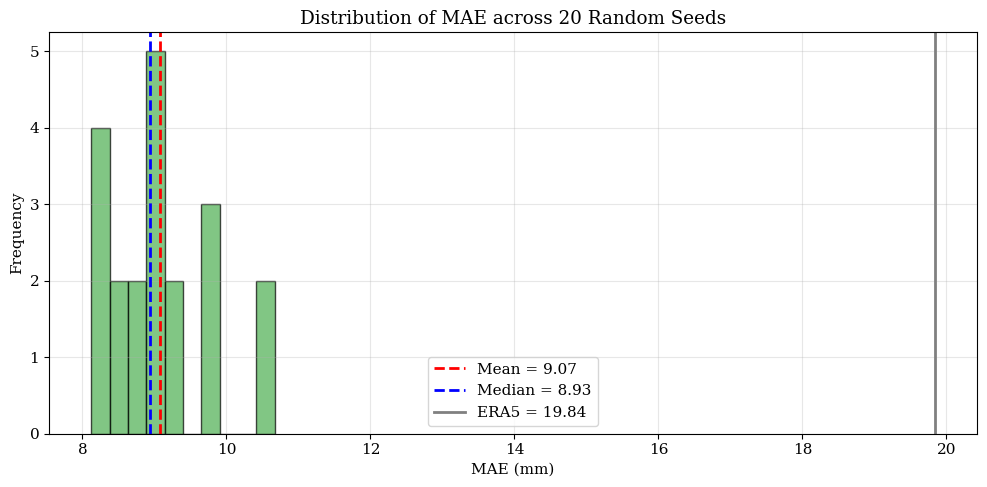

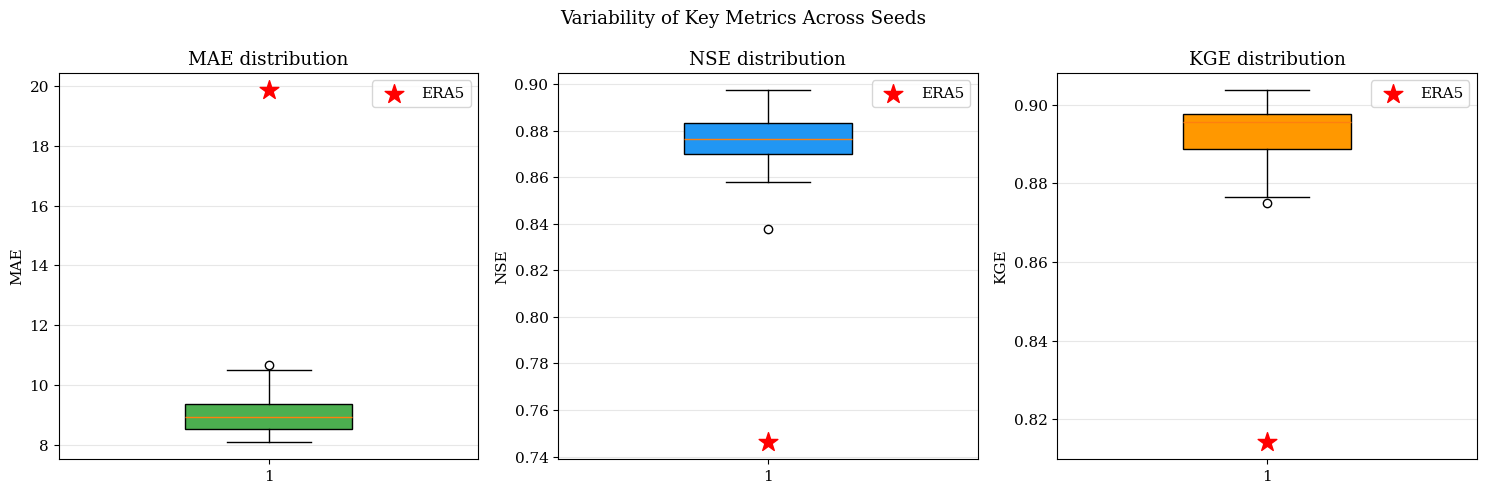

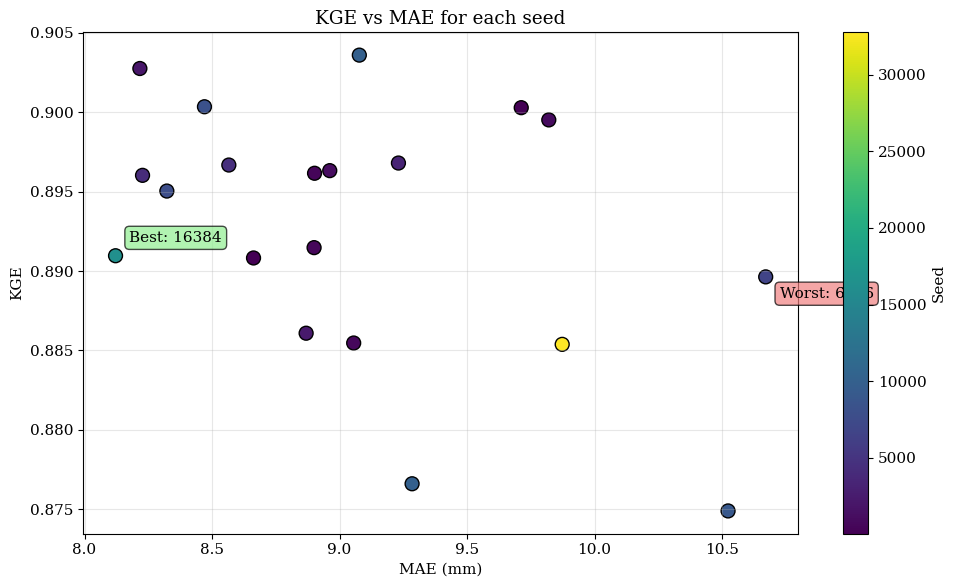

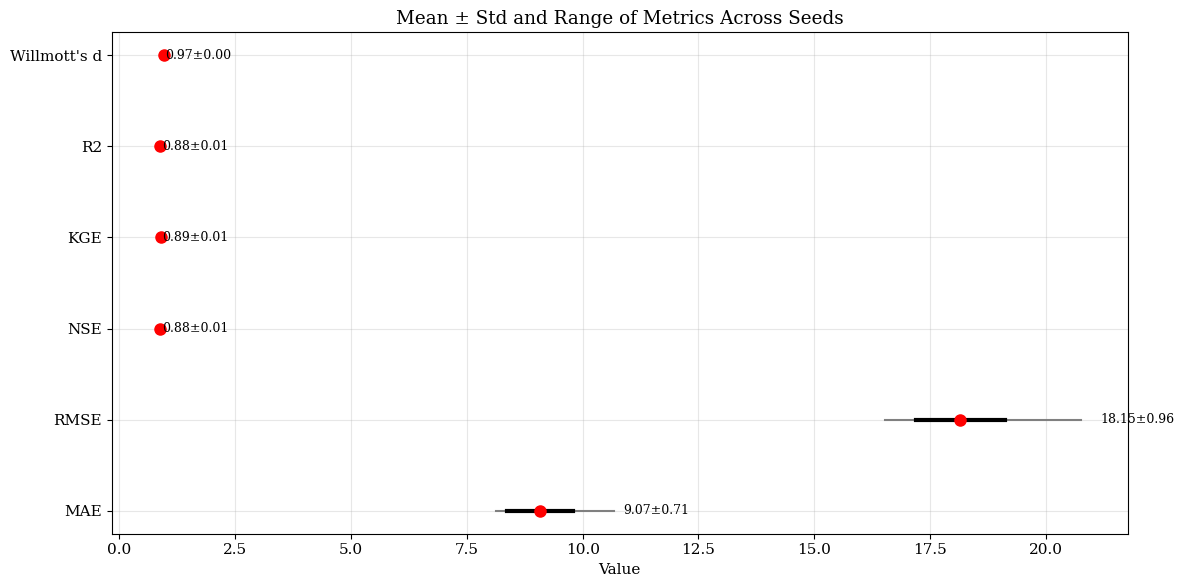

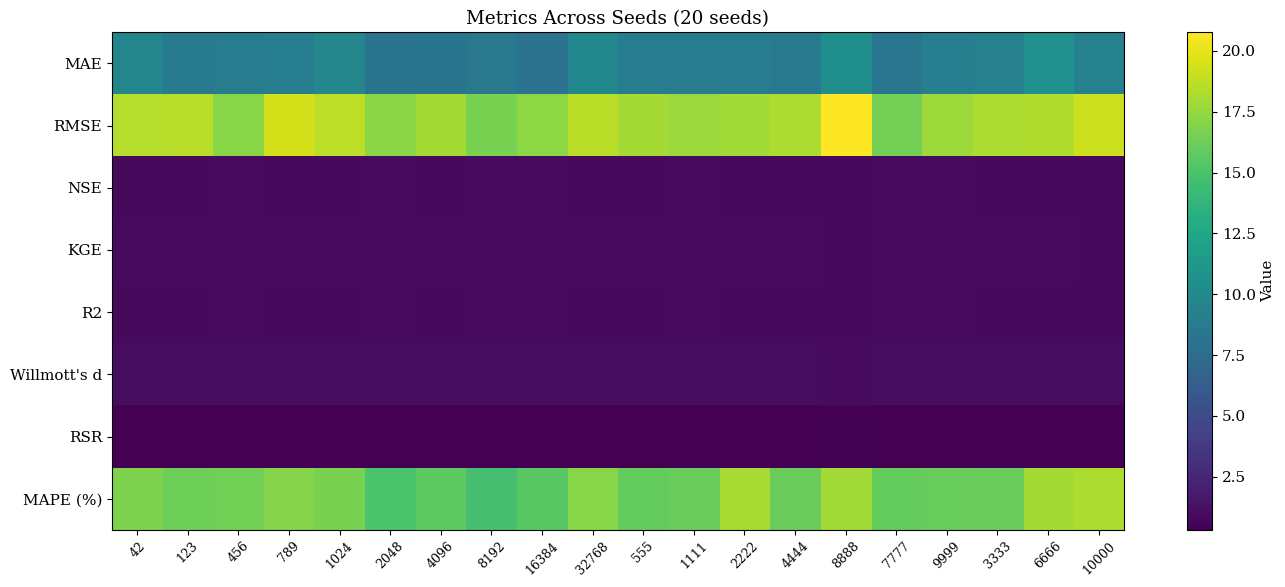

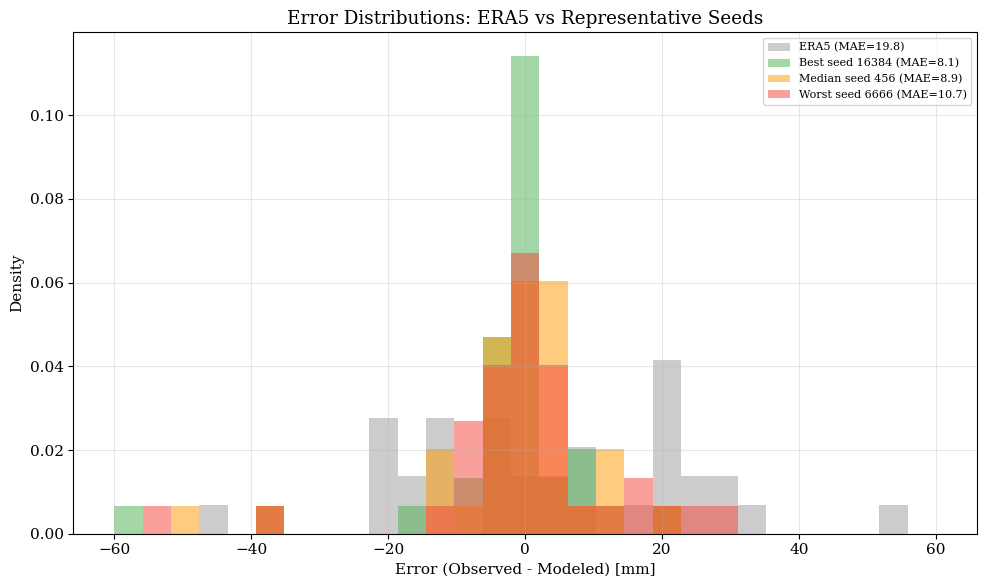


Representative seeds:
  Best    : seed= 16384, MAE=8.12 mm, NSE=0.888, KGE=0.891
  Median  : seed=   456, MAE=8.90 mm, NSE=0.889, KGE=0.896
  Worst   : seed=  6666, MAE=10.67 mm, NSE=0.874, KGE=0.890

✅ Seed sensitivity analysis completed.
Figures saved in figures/
Tables saved in tables/


In [ ]:
# ============================================================
# Supplementary: PINN seed sensitivity analysis
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Settings
# ============================================================
SEEDS = [42, 123, 456, 789, 1024, 2048, 4096, 8192, 16384, 32768,
        555, 1111, 2222, 4444, 8888, 7777, 9999, 3333, 6666, 10000]
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FIG_DIR = 'figures'
TABLE_DIR = 'tables'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

DATA_PATH = '../../data_preprocessing/processed/shemonaikha_snow_dataset_2014_2023.csv'
OBS_PATH  = '../../data_preprocessing/data/shemonaikha.csv'

print(f"Device: {DEVICE}")
print(f"Seeds: {len(SEEDS)}")

# ============================================================
# Load and prepare data
# ============================================================
print("\nLoading data...")
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['era5_swe'] = df['swe_final']

obs = pd.read_csv(OBS_PATH)
obs['Date'] = obs['Date'].astype(str).str.replace('"', '').str.strip()
obs['Date'] = obs['Date'].str.replace(',$', '', regex=True)
obs['Date'] = pd.to_datetime(obs['Date'], format='%d.%m.%Y %H:%M')
obs['SWE'] = pd.to_numeric(obs['SWE'].astype(str).str.replace('"', '').str.replace(',', ''), errors='coerce')
obs['date'] = obs['Date'].dt.date
obs = obs.drop_duplicates(subset=['date']).copy()
obs['date'] = pd.to_datetime(obs['date'])
station_dict = dict(zip(obs['date'], obs['SWE']))
df['observed_swe'] = df['date'].map(station_dict)

# Snow season only (Oct-May)
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['water_year'] = df['year'] + (df['month'] >= 10).astype(int)
df_snow = df[(df['month'] >= 10) | (df['month'] <= 5)].copy().reset_index(drop=True)

print(f"Snow season days: {len(df_snow)}")
print(f"Observations: {df_snow['observed_swe'].notna().sum()}")

# ============================================================
# Feature engineering
# ============================================================
def create_features(df_subset):
    n = len(df_subset)
    def get_vals(col):
        vals = df_subset[col]
        return vals.iloc[:, 0].values if isinstance(vals, pd.DataFrame) else vals.values

    temp = get_vals('temperature_2m_C')
    precip = get_vals('precipitation_mm')
    snow_cover = get_vals('snow_cover_ERA5')
    albedo = get_vals('forecast_albedo')
    snowmelt = get_vals('snowmelt_sum')
    solar_down = get_vals('surface_solar_radiation_downwards_sum')
    thermal_down = get_vals('surface_thermal_radiation_downwards_sum')
    u_wind = get_vals('u_component_of_wind_10m')
    v_wind = get_vals('v_component_of_wind_10m')
    soil_water = get_vals('volumetric_soil_water_layer_1')
    water_year = get_vals('water_year')
    doy = get_vals('doy')

    features = {}
    features['temperature_2m_C'] = temp
    features['precipitation_mm'] = precip
    features['snow_cover_ERA5'] = snow_cover
    features['forecast_albedo'] = albedo
    features['snowmelt_sum'] = snowmelt
    features['surface_solar_radiation_downwards_sum'] = solar_down
    features['surface_thermal_radiation_downwards_sum'] = thermal_down
    features['u_component_of_wind_10m'] = u_wind
    features['v_component_of_wind_10m'] = v_wind
    features['volumetric_soil_water_layer_1'] = soil_water

    features['wind_speed'] = np.sqrt(u_wind**2 + v_wind**2)
    albedo_clipped = np.clip(albedo, 0.3, 0.95)
    features['solar_net'] = solar_down * (1 - albedo_clipped)
    features['thermal_net'] = (thermal_down - 5.67e-8 * 273.15**4) / 1e6
    features['temp_melt_potential'] = np.maximum(temp - 0.5, 0)
    features['soil_moisture_pct'] = soil_water * 100
    features['doy_sin'] = np.sin(2 * np.pi * doy / 365)
    features['doy_cos'] = np.cos(2 * np.pi * doy / 365)

    unique_wy = np.unique(water_year)
    for lag in [1, 2, 3]:
        temp_lag = np.full(n, np.nan)
        precip_lag = np.full(n, np.nan)
        for wy in unique_wy:
            mask = water_year == wy
            idx = np.where(mask)[0]
            if len(idx) > lag:
                temp_lag[idx[lag:]] = temp[idx[:-lag]]
                precip_lag[idx[lag:]] = precip[idx[:-lag]]
        features[f'temp_lag{lag}'] = temp_lag
        features[f'precip_lag{lag}'] = precip_lag

    cumul_precip = np.full(n, np.nan)
    cumul_snowmelt = np.full(n, np.nan)
    for wy in unique_wy:
        mask = water_year == wy
        cumul_precip[mask] = np.cumsum(precip[mask])
        cumul_snowmelt[mask] = np.cumsum(snowmelt[mask])
    features['cumul_precip'] = cumul_precip
    features['cumul_snowmelt'] = cumul_snowmelt

    df_feat = pd.DataFrame(features, index=df_subset.index)
    df_feat = df_feat.ffill().fillna(0)
    return df_feat

# ============================================================
# PINN model
# ============================================================
class StablePINN(nn.Module):
    def __init__(self, feature_names):
        super().__init__()
        self.feature_names = feature_names
        self.raw_temp_melt = nn.Parameter(torch.tensor(0.5))
        self.raw_solar_melt = nn.Parameter(torch.tensor(-2.0))
        self.raw_thermal_melt = nn.Parameter(torch.tensor(-2.5))
        self.raw_wind_subl = nn.Parameter(torch.tensor(-3.0))
        self.raw_snow_threshold = nn.Parameter(torch.tensor(0.3))
        self.physics_weight = nn.Parameter(torch.tensor(0.5))
        self.era5_weight = nn.Parameter(torch.tensor(0.5))
        self.corrector = nn.Sequential(
            nn.Linear(12, 24),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(24, 12),
            nn.ReLU(),
            nn.Linear(12, 1),
            nn.Tanh()
        )
        self.correction_scale = nn.Parameter(torch.tensor(1.0))

    @property
    def temp_melt_factor(self):
        return torch.nn.functional.softplus(self.raw_temp_melt) * 2.0
    @property
    def solar_melt_factor(self):
        return torch.nn.functional.softplus(self.raw_solar_melt) * 0.05
    @property
    def thermal_melt_factor(self):
        return torch.nn.functional.softplus(self.raw_thermal_melt) * 0.01
    @property
    def wind_sublimation_factor(self):
        return torch.nn.functional.softplus(self.raw_wind_subl) * 0.01
    @property
    def snow_threshold(self):
        return torch.nn.functional.softplus(self.raw_snow_threshold) + 0.5

    def _get_idx(self, name):
        return self.feature_names.index(name)

    def physics_forward(self, x):
        t = x[:, self._get_idx('temperature_2m_C')]
        p = x[:, self._get_idx('precipitation_mm')]
        sc = x[:, self._get_idx('snow_cover_ERA5')] / 100.0
        sn = x[:, self._get_idx('solar_net')]
        tn = x[:, self._get_idx('thermal_net')]
        w = x[:, self._get_idx('wind_speed')]
        sm = x[:, self._get_idx('soil_moisture_pct')]
        tp = x[:, self._get_idx('temp_melt_potential')]

        snow_frac = torch.sigmoid(-3 * (t - self.snow_threshold))
        snowfall = p * snow_frac * torch.clamp(sc, min=0.05)
        temp_melt = self.temp_melt_factor * tp * sc
        solar_melt = self.solar_melt_factor * torch.clamp(sn, min=0) * sc
        thermal_melt = self.thermal_melt_factor * torch.clamp(tn, min=0) * sc
        soil_melt = 0.001 * sm * sc * tp
        sub_cond = torch.sigmoid(2 * (t + 5))
        sublimation = self.wind_sublimation_factor * w * sc * sub_cond
        total_melt = temp_melt + solar_melt + thermal_melt + soil_melt
        dswe_dt = snowfall - total_melt - sublimation
        return dswe_dt, snowfall, total_melt, sublimation

    def forward(self, x, swe_prev, era5_current, era5_prev):
        if x.dim() == 1:
            x = x.unsqueeze(0)
        dswe_dt, snowfall, total_melt, sublimation = self.physics_forward(x)
        swe_physics = swe_prev + dswe_dt.unsqueeze(1)
        swe_physics = torch.clamp(swe_physics, min=0)
        w_phys = torch.sigmoid(self.physics_weight)
        w_era5 = torch.sigmoid(self.era5_weight)
        swe_blend = (w_phys * swe_physics + w_era5 * era5_current) / (w_phys + w_era5 + 1e-8)
        corr_features = torch.cat([
            dswe_dt.unsqueeze(1), snowfall.unsqueeze(1),
            total_melt.unsqueeze(1), sublimation.unsqueeze(1),
            (swe_physics - era5_current), (swe_prev - era5_prev),
            x[:, self._get_idx('temperature_2m_C')].unsqueeze(1),
            x[:, self._get_idx('snow_cover_ERA5')].unsqueeze(1) / 100.0,
            x[:, self._get_idx('cumul_precip')].unsqueeze(1) / 200.0,
            x[:, self._get_idx('cumul_snowmelt')].unsqueeze(1) / 200.0,
            x[:, self._get_idx('doy_sin')].unsqueeze(1),
            x[:, self._get_idx('doy_cos')].unsqueeze(1)
        ], dim=1)
        scale = torch.nn.functional.softplus(self.correction_scale) * 10.0
        correction = self.corrector(corr_features) * scale
        swe_corrected = swe_blend + correction
        swe_corrected = torch.clamp(swe_corrected, min=0)
        return swe_corrected, swe_physics, correction

    def run_sequence(self, X, era5_swe, warmup_steps=10):
        seq_len = X.shape[0]
        swe_pred = torch.zeros(seq_len, 1, device=X.device)
        swe_physics_out = torch.zeros(seq_len, 1, device=X.device)
        corr_out = torch.zeros(seq_len, 1, device=X.device)
        swe_pred[0] = era5_swe[0]
        swe_physics_out[0] = era5_swe[0]
        for t in range(1, seq_len):
            swe_pred[t], swe_physics_out[t], corr_out[t] = self(
                X[t:t+1], swe_pred[t-1:t],
                era5_swe[t:t+1], era5_swe[t-1:t]
            )
        warmup_mask = torch.zeros(seq_len, 1, dtype=torch.bool, device=X.device)
        warmup_mask[:warmup_steps] = True
        return swe_pred, swe_physics_out, corr_out, warmup_mask

def stable_loss(swe_pred, era5, obs, correction, active_mask):
    obs_mask = ~torch.isnan(obs) & active_mask
    if obs_mask.sum() > 0:
        diff = torch.abs(swe_pred[obs_mask] - obs[obs_mask])
        loss_obs = torch.where(diff < 10.0, 0.5 * diff**2, 10.0 * diff - 50.0).mean()
    else:
        loss_obs = torch.tensor(0.0, device=swe_pred.device)
    loss_era5 = torch.mean((swe_pred[active_mask] - era5[active_mask])**2) * 0.01
    loss_corr = torch.mean(correction[active_mask]**2) * 0.1
    swe_active = swe_pred[active_mask]
    loss_smooth = torch.mean(torch.abs(swe_active[1:] - swe_active[:-1])) * 0.001 if swe_active.shape[0] > 1 else torch.tensor(0.0, device=swe_pred.device)
    return loss_obs + loss_era5 + loss_corr + loss_smooth, loss_obs

# ============================================================
# Metrics
# ============================================================
def nse(y_true, y_pred):
    return 1 - np.sum((y_true - y_pred)**2) / (np.sum((y_true - np.mean(y_true))**2) + 1e-10)

def kge(y_true, y_pred):
    r = np.corrcoef(y_true, y_pred)[0,1]
    alpha = np.std(y_pred) / (np.std(y_true) + 1e-10)
    beta = np.mean(y_pred) / (np.mean(y_true) + 1e-10)
    return 1 - np.sqrt((r-1)**2 + (alpha-1)**2 + (beta-1)**2)

def willmott_d(y_true, y_pred):
    return 1 - np.sum((y_pred - y_true)**2) / np.sum((np.abs(y_pred - np.mean(y_true)) + np.abs(y_true - np.mean(y_true)))**2 + 1e-10)

def pbias(y_true, y_pred):
    return 100 * np.sum(y_pred - y_true) / (np.sum(y_true) + 1e-10)

def rsr(y_true, y_pred):
    return np.sqrt(np.sum((y_true - y_pred)**2)) / (np.sqrt(np.sum((y_true - np.mean(y_true))**2)) + 1e-10)

def mape(y_true, y_pred):
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan

def smape(y_true, y_pred):
    return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-10)) * 100

def explained_variance(y_true, y_pred):
    return 1 - np.var(y_true - y_pred) / (np.var(y_true) + 1e-10)

def full_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0,1]
    nse_val = nse(y_true, y_pred)
    kge_val = kge(y_true, y_pred)
    d = willmott_d(y_true, y_pred)
    pb = pbias(y_true, y_pred)
    rs = rsr(y_true, y_pred)
    mp = mape(y_true, y_pred)
    sm = smape(y_true, y_pred)
    ev = explained_variance(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'NSE': nse_val, 'KGE': kge_val,
            "Willmott's d": d, 'PBIAS (%)': pb, 'RSR': rs, 'MAPE (%)': mp,
            'SMAPE (%)': sm, 'Explained Var': ev, 'Pearson r': corr}

# ============================================================
# Prepare targets and indices
# ============================================================
obs_dates = df_snow[df_snow['observed_swe'].notna()]['date'].values
obs_indices = [df_snow[df_snow['date'] == d].index[0] for d in obs_dates]
y_true = df_snow.loc[obs_indices, 'observed_swe'].values.astype(float)
era5_true = df_snow.loc[obs_indices, 'era5_swe'].values.astype(float)

# ============================================================
# LOO for each seed
# ============================================================
print(f"\nRunning LOO for {len(SEEDS)} seeds...")
results = []
predictions_per_seed = {}  # seed -> array of predictions

for seed in SEEDS:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    preds = []
    corrections = []

    for test_idx in obs_indices:
        start_idx = max(0, test_idx - 89)
        df_subset = df_snow.iloc[start_idx:test_idx+1].copy()
        df_features = create_features(df_subset)
        feature_names = df_features.columns.tolist()
        scaler = RobustScaler()
        scaled_feat = scaler.fit_transform(df_features.values)
        X = torch.FloatTensor(scaled_feat).to(DEVICE)
        era5 = torch.FloatTensor(df_subset['era5_swe'].values.reshape(-1, 1)).to(DEVICE)
        obs = torch.FloatTensor(df_subset['observed_swe'].values.reshape(-1, 1)).to(DEVICE)

        model = StablePINN(feature_names).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
        for epoch in range(50):
            optimizer.zero_grad()
            swe_pred, _, corr, warmup = model.run_sequence(X, era5, warmup_steps=10)
            active = ~warmup
            loss, _ = stable_loss(swe_pred, era5, obs, corr, active)
            if not torch.isnan(loss):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        model.eval()
        with torch.no_grad():
            swe_pred, _, corr, _ = model.run_sequence(X, era5, warmup_steps=0)
            preds.append(max(0, swe_pred[-1].item()))
            corrections.append(corr[-1].item())

    preds = np.array(preds)
    corrections = np.array(corrections)
    predictions_per_seed[seed] = preds

    m = full_metrics(y_true, preds)
    errors_era5 = np.abs(y_true - era5_true)
    errors_pinn = np.abs(y_true - preds)
    _, p_val = stats.wilcoxon(errors_era5, errors_pinn)
    improved_pct = np.mean(errors_pinn < errors_era5) * 100

    results.append({
        'seed': seed,
        **m,
        'p_value': p_val,
        'improved_%': improved_pct,
        'mean_correction': np.mean(corrections),
        'std_correction': np.std(corrections),
        'max_abs_correction': np.max(np.abs(corrections))
    })
    print(f"Seed {seed:6d}: MAE={m['MAE']:5.2f} mm, NSE={m['NSE']:.3f}, KGE={m['KGE']:.3f}, p={p_val:.4f}")

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(TABLE_DIR, 'pinn_seed_sensitivity_metrics.csv'), index=False)
print(f"\nResults saved to {TABLE_DIR}/pinn_seed_sensitivity_metrics.csv")

# ============================================================
# Summary statistics
# ============================================================
summary = {}
for metric in ['MAE', 'RMSE', 'NSE', 'KGE', 'R2', "Willmott's d", 'PBIAS (%)', 'RSR', 'MAPE (%)', 'SMAPE (%)', 'Explained Var', 'Pearson r']:
    vals = results_df[metric].values
    summary[metric] = {
        'mean': np.mean(vals),
        'std': np.std(vals),
        'min': np.min(vals),
        'max': np.max(vals),
        'cv': np.std(vals) / (np.mean(vals) + 1e-10) * 100
    }

summary_df = pd.DataFrame(summary).T
summary_df.to_csv(os.path.join(TABLE_DIR, 'pinn_seed_sensitivity_summary.csv'))

print("\n" + "="*80)
print("SUMMARY STATISTICS ACROSS SEEDS")
print("="*80)
print(summary_df.round(3).to_string())

# ============================================================
# Plots
# ============================================================
plt.rcParams.update({'font.size': 11, 'font.family': 'serif', 'mathtext.fontset': 'stix'})

# 1. Histogram of MAE
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(results_df['MAE'], bins=10, edgecolor='black', alpha=0.7, color='#4CAF50')
ax.axvline(results_df['MAE'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean = {results_df['MAE'].mean():.2f}")
ax.axvline(results_df['MAE'].median(), color='blue', linestyle='--', linewidth=2, label=f"Median = {results_df['MAE'].median():.2f}")
ax.axvline(mean_absolute_error(y_true, era5_true), color='gray', linewidth=2, label=f'ERA5 = {mean_absolute_error(y_true, era5_true):.2f}')
ax.set_xlabel('MAE (mm)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of MAE across 20 Random Seeds')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pinn_seed_sensitivity_hist.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'pinn_seed_sensitivity_hist.pdf'), bbox_inches='tight')
plt.show()

# 2. Boxplots for key metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_to_box = ['MAE', 'NSE', 'KGE']
colors_box = ['#4CAF50', '#2196F3', '#FF9800']
for ax, metric, color in zip(axes, metrics_to_box, colors_box):
    if metric == 'MAE':
        era5_val = mean_absolute_error(y_true, era5_true)
    elif metric == 'NSE':
        era5_val = nse(y_true, era5_true)
    else:
        era5_val = kge(y_true, era5_true)
    data = results_df[metric].values
    bp = ax.boxplot(data, patch_artist=True, widths=0.4)
    bp['boxes'][0].set_facecolor(color)
    ax.scatter(1, era5_val, marker='*', s=200, color='red', label='ERA5', zorder=10)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} distribution')
    ax.grid(alpha=0.3, axis='y')
    ax.legend()
plt.suptitle('Variability of Key Metrics Across Seeds')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pinn_seed_sensitivity_boxplots.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'pinn_seed_sensitivity_boxplots.pdf'), bbox_inches='tight')
plt.show()

# 3. Scatter MAE vs KGE
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(results_df['MAE'], results_df['KGE'], c=results_df['seed'], cmap='viridis', s=100, edgecolors='black')
ax.set_xlabel('MAE (mm)')
ax.set_ylabel('KGE')
ax.set_title('KGE vs MAE for each seed')
cbar = plt.colorbar(sc, ax=ax, label='Seed')
ax.grid(alpha=0.3)
best_idx = results_df['MAE'].idxmin()
worst_idx = results_df['MAE'].idxmax()
ax.annotate(f"Best: {results_df.loc[best_idx, 'seed']}", (results_df.loc[best_idx, 'MAE'], results_df.loc[best_idx, 'KGE']),
            xytext=(10, 10), textcoords='offset points', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
ax.annotate(f"Worst: {results_df.loc[worst_idx, 'seed']}", (results_df.loc[worst_idx, 'MAE'], results_df.loc[worst_idx, 'KGE']),
            xytext=(10, -15), textcoords='offset points', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pinn_seed_sensitivity_scatter.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'pinn_seed_sensitivity_scatter.pdf'), bbox_inches='tight')
plt.show()

# 4. Range plot (mean ± std, min-max)
metrics_range = ['MAE', 'RMSE', 'NSE', 'KGE', 'R2', "Willmott's d"]
fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(metrics_range))
for i, metric in enumerate(metrics_range):
    vals = results_df[metric].values
    mean_val = np.mean(vals)
    std_val = np.std(vals)
    min_val = np.min(vals)
    max_val = np.max(vals)
    ax.plot([min_val, max_val], [i, i], color='gray', linewidth=1.5)
    ax.plot([mean_val - std_val, mean_val + std_val], [i, i], color='black', linewidth=3)
    ax.plot([mean_val], [i], 'o', color='red', markersize=8)
    ax.text(max_val + 0.02*max_val, i, f'{mean_val:.2f}±{std_val:.2f}', va='center', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(metrics_range)
ax.set_xlabel('Value')
ax.set_title('Mean ± Std and Range of Metrics Across Seeds')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pinn_seed_sensitivity_range.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'pinn_seed_sensitivity_range.pdf'), bbox_inches='tight')
plt.show()

# 5. Heatmap of metrics across seeds
heat_metrics = ['MAE', 'RMSE', 'NSE', 'KGE', 'R2', "Willmott's d", 'RSR', 'MAPE (%)']
heat_data = results_df[heat_metrics].values.T
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heat_data, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(SEEDS)))
ax.set_xticklabels(results_df['seed'].values, rotation=45, fontsize=9)
ax.set_yticks(range(len(heat_metrics)))
ax.set_yticklabels(heat_metrics)
ax.set_title('Metrics Across Seeds (20 seeds)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Value')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pinn_seed_sensitivity_heatmap.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'pinn_seed_sensitivity_heatmap.pdf'), bbox_inches='tight')
plt.show()

# 6. Error distributions for best, median, worst seeds
fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(-60, 60, 30)
ax.hist(y_true - era5_true, bins=bins, alpha=0.4, color='gray', density=True, label=f'ERA5 (MAE={mean_absolute_error(y_true, era5_true):.1f})')

best_idx = results_df['MAE'].idxmin()
worst_idx = results_df['MAE'].idxmax()
median_idx = results_df['MAE'].sub(results_df['MAE'].median()).abs().idxmin()

for idx, label, color in [
    (best_idx, f"Best seed {results_df.loc[best_idx, 'seed']} (MAE={results_df.loc[best_idx, 'MAE']:.1f})", '#4CAF50'),
    (median_idx, f"Median seed {results_df.loc[median_idx, 'seed']} (MAE={results_df.loc[median_idx, 'MAE']:.1f})", '#FF9800'),
    (worst_idx, f"Worst seed {results_df.loc[worst_idx, 'seed']} (MAE={results_df.loc[worst_idx, 'MAE']:.1f})", '#F44336')
]:
    seed_val = results_df.loc[idx, 'seed']
    preds_for_seed = predictions_per_seed[seed_val]
    ax.hist(y_true - preds_for_seed, bins=bins, alpha=0.5, color=color, density=True, label=label)

ax.set_xlabel('Error (Observed - Modeled) [mm]')
ax.set_ylabel('Density')
ax.set_title('Error Distributions: ERA5 vs Representative Seeds')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pinn_seed_sensitivity_error_dist.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'pinn_seed_sensitivity_error_dist.pdf'), bbox_inches='tight')
plt.show()

# ============================================================
# Print summary of representative seeds
# ============================================================
print("\nRepresentative seeds:")
for idx, label in [(best_idx, 'Best'), (median_idx, 'Median'), (worst_idx, 'Worst')]:
    row = results_df.loc[idx]
    print(f"  {label:8s}: seed={int(row['seed']):6d}, MAE={row['MAE']:.2f} mm, NSE={row['NSE']:.3f}, KGE={row['KGE']:.3f}")

print("\n✅ Seed sensitivity analysis completed.")
print(f"Figures saved in {FIG_DIR}/")
print(f"Tables saved in {TABLE_DIR}/")